In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
plt.rcParams.update(
    {
        "font.family": "serif",  # use serif/main font for text elements
        "text.usetex": True,  # use inline math for ticks
        "pgf.rcfonts": False,  # don't setup fonts from rc parameters
        "axes.labelsize": 14,  # axis labels
        "legend.fontsize": 12,  # legend
        "xtick.labelsize": 12,  # x tick labels
        "ytick.labelsize": 12,  # y tick labels
    }
)

In [3]:
# get the total energy from the OUTCAR file
def get_total_energy(outcar_file):
    with open(outcar_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'free  energy   TOTEN' in line:
                energy = float(line.split()[4])
                return energy
    return None

In [4]:
encuts = []
energies = []

encut_path = Path("encut_convergence")

subfolders = os.listdir(encut_path)
subfolders = [f for f in subfolders if not f.endswith(".tex")]
# sort the subfolders by encut value
subfolders.sort(key=lambda x: int(x.split("_")[1]))

for subfolder in subfolders:
    if subfolder.startswith("encut_"):
        encut_value = int(subfolder.split("_")[1])
        energy = get_total_energy(encut_path / subfolder / "OUTCAR")
        if energy is not None:
            encuts.append(encut_value)
            energies.append(energy)

data = pd.DataFrame({'ENCUT': encuts, 'Total Energy (eV)': energies})
data["energy difference"] = data["Total Energy (eV)"].diff().abs()
data["energy difference per atom (meV)"] = (data["energy difference"] / 12) * 1000  # divide by number of atoms and convert to meV
data

,ENCUT,Total Energy (eV),energy difference,energy difference per atom (meV)
0,100,773.594306,NaN,NaN
1,200,-99.477468,873.071775,72755.981214
2,300,-103.356862,3.879394,323.282797
3,350,-103.308756,0.048106,4.008828
4,400,-103.358881,0.050125,4.177107
5,450,-103.361483,0.002601,0.216784
6,500,-103.341549,0.019934,1.661131
7,600,-103.347179,0.005630,0.469172
8,700,-103.363653,0.016473,1.372786
9,800,-103.370334,0.006681,0.556780


In [5]:
subset = data[["ENCUT", "energy difference per atom (meV)"]]
# format the energy difference to 2 decimal places
subset["energy difference per atom (meV)"] = subset["energy difference per atom (meV)"].apply(lambda x: f"{x:.2f}")
subset = subset.iloc[2:]  # drop the first row which has NaN for energy difference
subset.to_latex("encut_convergence/encut_convergence_table.tex", index=False, escape=False)

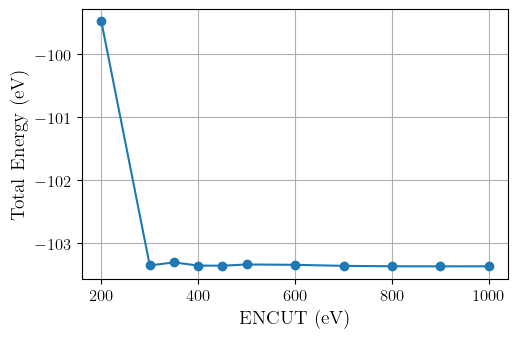

In [6]:
subset = data.iloc[1:]

plt.figure(figsize=(5.5, 3.5))

plt.plot(subset["ENCUT"], subset["Total Energy (eV)"], marker='o')
plt.grid()
plt.xlabel(r'ENCUT (eV)')
plt.ylabel(r'Total Energy (eV)')

plt.savefig("output/encut_convergence_plot.pdf", bbox_inches='tight', format='pdf')

In [7]:
# kpoints convergence results
subfolders = os.listdir("kpoints_convergence")
subfolders = [f for f in subfolders if not f.endswith(".tex")]

kpoints = []
energies = []

# sort the subfolders by kpoints value
subfolders.sort(key=lambda x: int(x.split("_")[1]))

for subfolder in subfolders:
    if subfolder.startswith("kpoints_"):
        kpoints_value = int(subfolder.split("_")[1])
        energy = get_total_energy(f'kpoints_convergence/{subfolder}/OUTCAR')
        if energy is not None:
            kpoints.append(kpoints_value)
            energies.append(energy)

kpoints_data = pd.DataFrame({'K-Points': kpoints, 'Total Energy (eV)': energies})
kpoints_data["energy difference"] = kpoints_data["Total Energy (eV)"].diff().abs()
kpoints_data["energy difference per atom (meV)"] = (kpoints_data["energy difference"] / 12) * 1000  # divide by number of atoms and convert to meV
kpoints_data

,K-Points,Total Energy (eV),energy difference,energy difference per atom (meV)
0,1,-101.281162,NaN,NaN
1,2,-104.314494,3.033332,252.777706
2,3,-102.510878,1.803616,150.301322
3,4,-103.352677,0.841799,70.149912
4,5,-103.179333,0.173344,14.445367
5,6,-103.294938,0.115605,9.633724
6,7,-103.270175,0.024763,2.063568
7,8,-103.289014,0.018839,1.569895
8,9,-103.284096,0.004917,0.409779
9,10,-103.287690,0.003594,0.299486


In [8]:
subset_kpoints = kpoints_data[["K-Points", "energy difference per atom (meV)"]]
# format the energy difference to 2 decimal places
subset_kpoints["energy difference per atom (meV)"] = subset_kpoints["energy difference per atom (meV)"].apply(lambda x: f"{x:.2f}")
subset_kpoints = subset_kpoints.iloc[2:]  # drop the first row which has NaN for energy difference
subset_kpoints.to_latex("kpoints_convergence/kpoints_convergence_table.tex", index=False, escape=False)

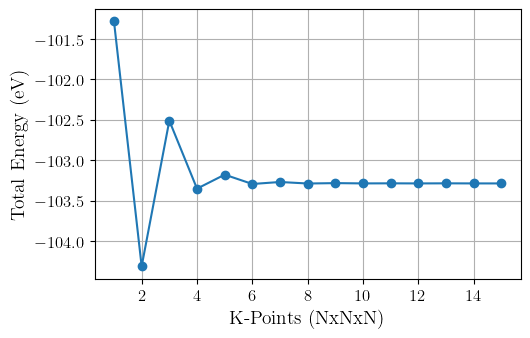

In [9]:
plt.figure(figsize=(5.5, 3.5))

plt.plot(kpoints, energies, marker='o')
plt.xlabel('K-Points (NxNxN)')
plt.ylabel('Total Energy (eV)')
plt.grid()

plt.savefig("output/kpoints_convergence_plot.pdf", bbox_inches='tight', format='pdf')